# Notebook 07 — Model Interpretation
### WID2003 Cognitive Science | FSKTM, Universiti Malaya

---

## Overview

Knowing that a model predicts well is only half the story. This notebook uses **SHAP (SHapley Additive exPlanations)** to explain *why* the model makes each prediction — and then maps those explanations back to cognitive science constructs.

**Inputs**
| File | Description |
|---|---|
| `outputs/models/trained_model.pkl` | Best model from Notebook 06 |
| `outputs/models/model_metadata.json` | Model name, CV score, feature list |
| `data/processed/dataset_final.parquet` | Feature matrix |
| `data/processed/labels.csv` | Actual performance labels |

**Outputs**
| File | Description |
|---|---|
| `outputs/figures/07_shap_beeswarm.png` | SHAP summary plot — top features across all participants |
| `outputs/figures/07_shap_dependence.png` | Dependence plots for top 3 features |
| `outputs/figures/07_shap_waterfall_*.png` | Per-participant waterfall plots (correct, correct, misclassified) |
| `outputs/reports/participant_predictions.csv` | Actual label, predicted label, probability, top SHAP feature |
| `outputs/reports/07_cognitive_interpretation.csv` | Feature → cognitive construct mapping |

---

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the **SHAP framework** — what a Shapley value represents, and how it satisfies the efficiency, symmetry, and dummy player axioms
2. Interpret a **SHAP beeswarm (summary) plot** — identify which features matter most and in which direction
3. Read a **SHAP dependence plot** and identify the relationship between a feature value and its impact on prediction
4. Read a **SHAP waterfall plot** for an individual participant and explain which features drove the model's prediction for that person
5. Map quantitative SHAP findings back onto **cognitive science constructs** (attention, working memory, search strategy) to produce a meaningful narrative

---

## Background

### Why Interpretability Matters

A classifier that predicts "High" or "Low" without explanation is not useful to educators or researchers. Interpretability answers:
- **Which eye-tracking features best distinguish the groups?** → guides future study design
- **Why was this specific participant misclassified?** → reveals boundary cases
- **Does the model's behaviour align with cognitive theory?** → validates or challenges hypotheses

### SHAP — Shapley Additive Explanations

SHAP decomposes each model prediction into the **contribution of each feature**, grounded in cooperative game theory (Shapley values from economics).

For a prediction f(x) on one participant:

```
f(x) = E[f(X)]  +  φ₁  +  φ₂  +  ...  +  φₚ
        base value    feature contributions (SHAP values)
```

A **positive SHAP value** for a feature pushes the prediction toward High (label = 1).  
A **negative SHAP value** pushes toward Low (label = 0).

The **base value** E[f(X)] is the model's average prediction across all training participants — the starting point before any features are considered.

### Choosing the SHAP Explainer

| Model type | SHAP explainer | Speed |
|---|---|---|
| Random Forest, Decision Tree | `TreeExplainer` | Fast (exact) |
| Logistic Regression | `LinearExplainer` | Fast (exact) |
| SVM, KNN, other | `KernelExplainer` | Slow (approximate) |

### SHAP Plot Types

**Beeswarm (summary) plot**  
Shows all participants for all top features. Each dot is one participant; position on x-axis shows the SHAP value (direction of impact); colour shows whether the feature value was high (red) or low (blue). This is the most information-dense single view of the model.

**Dependence plot**  
Shows the SHAP value for one feature (y-axis) vs. the raw feature value (x-axis) across all participants. Reveals non-linear relationships and interactions. A second feature is shown as colour to reveal interaction effects.

**Waterfall plot**  
Shows one participant's prediction broken into feature-by-feature contributions, starting from the base value and ending at the final prediction. The most useful plot for explaining why a specific participant was classified a certain way — or misclassified.

### Cognitive Construct Mapping

| Eye-tracking feature | Cognitive construct |
|---|---|
| Time to first fixation on `answer` | Speed of target detection |
| Correct AOI dwell ratio | Focus on relevant information |
| Distractor dwell ratio | Susceptibility to irrelevant stimuli |
| Average fixation duration | Depth of processing per location |
| Number of fixations | Breadth and efficiency of visual search |
| Scanpath length | Directness of search path |
| Re-fixation count | Confirmation / checking behaviour |
| Pupil dilation change | Cognitive load variation over the trial |
| Saccade peak velocity | Decisiveness and directedness of eye movement |

---

## Discussion Questions

1. A feature has a SHAP value of +0.32 for participant A and −0.18 for participant B, but both have the same raw feature value (e.g., fixation duration = 850 ms). How is this possible, and what does it tell you about SHAP?
2. The beeswarm plot shows `distractor_dwell_ratio` as the second most important feature. High values push toward Low (negative SHAP). A student argues: "We already knew looking at wrong areas is bad — this tells us nothing new." Respond to this argument with two specific points about what SHAP adds over simple group mean comparisons.
3. A participant is misclassified as High when they are actually Low. Their waterfall plot shows `correct_aoi_dwell_ratio` contributed +0.4 to the prediction. What does this mean, and what might explain the mismatch with their actual performance label?
4. The study's original hypothesis was: "High-performing students will show shorter time to the target area, higher dwell time on the correct region, and fewer unnecessary fixations." Do the SHAP results support or contradict this hypothesis? Which task-level features provide the strongest evidence?
5. You plan to communicate findings to non-technical stakeholders (e.g., a course coordinator). Summarise the three most important findings from this notebook in plain language, without using the terms "SHAP", "model", or "classifier".

In [1]:
import sys
sys.path.insert(0, '..')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("shap not installed. Run: pip install shap")
    SHAP_AVAILABLE = False

from src.config import (
    DATASET_FINAL, LABELS_CSV, OUTPUTS_MODELS, OUTPUTS_REPORTS, OUTPUTS_FIGURES,
    PERFORMANCE_LABEL_COL
)

sns.set_theme(style='whitegrid')
for p in [OUTPUTS_REPORTS, OUTPUTS_FIGURES]:
    p.mkdir(parents=True, exist_ok=True)

## 1. Load model and data

In [2]:
model = joblib.load(OUTPUTS_MODELS / 'trained_model.pkl')
with open(OUTPUTS_MODELS / 'model_metadata.json') as f:
    metadata = json.load(f)

print(f"Loaded model: {metadata['best_model_name']}")
print(f"CV balanced accuracy: {metadata['cv_balanced_accuracy']:.3f}")
print(f"Permutation p-value:  {metadata['permutation_p_value']:.4f}")

dataset = pd.read_parquet(DATASET_FINAL)
labels  = pd.read_csv(LABELS_CSV)

feature_cols = metadata['feature_col_names']
X = dataset[feature_cols].values
y = dataset[PERFORMANCE_LABEL_COL].astype(int).values

# Refit on full dataset for SHAP
model.fit(X, y)

print(f"\nParticipants: {len(dataset)}, Features: {len(feature_cols)}")

Loaded model: Logistic Regression
CV balanced accuracy: 0.500
Permutation p-value:  1.0000

Participants: 8, Features: 267


/home/wlsoo/WID2003/wid2003_venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  1   5   9  13  17  21  25  29  33  37  45  53  61  64  65  66  67  68
  69  70  71  73  75  77  79  81  85  89  93  97 101 105 109 117 125 133
 141 229] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/wlsoo/WID2003/wid2003_venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


## 2. Built-in feature importance (tree models) / coefficient magnitude (linear models)

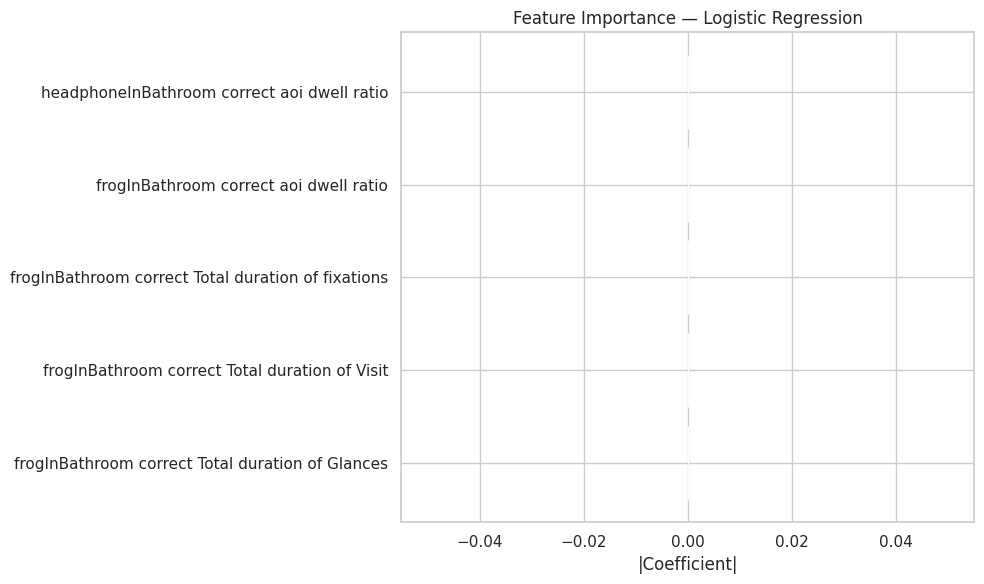

In [3]:
# Get selected feature names from SelectKBest step
selector = model.named_steps['select']
selected_mask  = selector.get_support()
selected_names = [feature_cols[i] for i, s in enumerate(selected_mask) if s]

clf = model.named_steps['clf']

# Extract importances / coefficients
importances = None
imp_label = 'Feature Importance'

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    imp_label = 'Gini Importance'
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0]) if clf.coef_.ndim > 1 else np.abs(clf.coef_)
    imp_label = '|Coefficient|'

if importances is not None:
    imp_df = pd.DataFrame({
        'feature':    selected_names,
        'importance': importances
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(imp_df)*0.35)))
    ax.barh(imp_df['feature'].str.replace('_', ' '), imp_df['importance'],
            color='steelblue', edgecolor='white')
    ax.set_xlabel(imp_label)
    ax.set_title(f'Feature Importance — {metadata["best_model_name"]}')
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / '07_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No built-in feature importance for this model type.")

## 3. SHAP analysis

In [4]:
if SHAP_AVAILABLE:
    # Transform X through SelectKBest for SHAP
    X_selected = selector.transform(X)

    # Choose explainer based on model type
    clf_type = type(clf).__name__
    print(f"Creating SHAP explainer for {clf_type}...")

    if clf_type in ('RandomForestClassifier', 'DecisionTreeClassifier', 'GradientBoostingClassifier'):
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_selected)
        # shap_values can be:
        #   list of 2 arrays  → [class0, class1], each (n_samples, n_features)
        #   3D ndarray        → (n_samples, n_features, n_classes)  [newer SHAP]
        if isinstance(shap_values, list):
            sv = shap_values[1]                    # class 1 (High)
        elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
            sv = shap_values[:, :, 1]              # class 1 slice → (n_samples, n_features)
        else:
            sv = shap_values                       # already (n_samples, n_features)
    elif clf_type == 'LogisticRegression':
        explainer = shap.LinearExplainer(clf, X_selected)
        sv = explainer.shap_values(X_selected)
        if isinstance(sv, list):
            sv = sv[1]
        elif isinstance(sv, np.ndarray) and sv.ndim == 3:
            sv = sv[:, :, 1]
    else:
        # Fallback: KernelExplainer (slow but universal)
        background = shap.kmeans(X_selected, min(10, len(X_selected)))
        explainer = shap.KernelExplainer(clf.predict_proba, background)
        sv = explainer.shap_values(X_selected)[:, :, 1]  # class 1

    # Guarantee sv is 2D: (n_samples, n_features)
    sv = np.array(sv)
    if sv.ndim == 1:
        sv = sv[np.newaxis, :]
    assert sv.ndim == 2, f"Unexpected sv shape: {sv.shape}"
    print(f"SHAP values computed. sv shape: {sv.shape}")
else:
    print("Skipping SHAP — library not installed.")

Creating SHAP explainer for LogisticRegression...
SHAP values computed. sv shape: (8, 5)


Generating SHAP beeswarm plot...


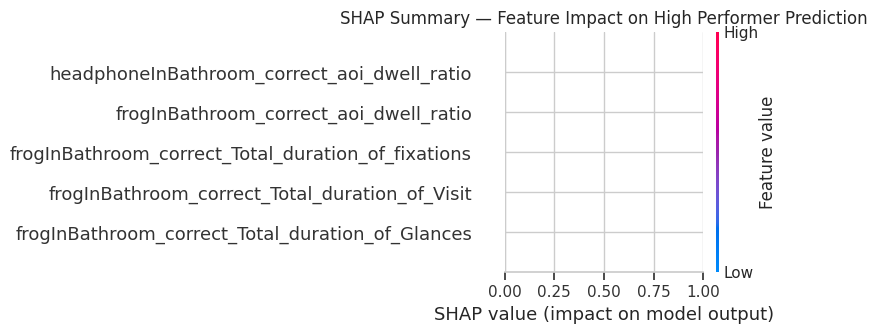

In [5]:
if SHAP_AVAILABLE:
    # Beeswarm summary plot
    print("Generating SHAP beeswarm plot...")
    shap.summary_plot(
        sv, X_selected,
        feature_names=selected_names,
        plot_type='beeswarm', show=False
    )
    plt.title('SHAP Summary — Feature Impact on High Performer Prediction')
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / '07_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

Top 3 SHAP features: ['headphoneInBathroom_correct_aoi_dwell_ratio', 'frogInBathroom_correct_aoi_dwell_ratio', 'frogInBathroom_correct_Total_duration_of_fixations']


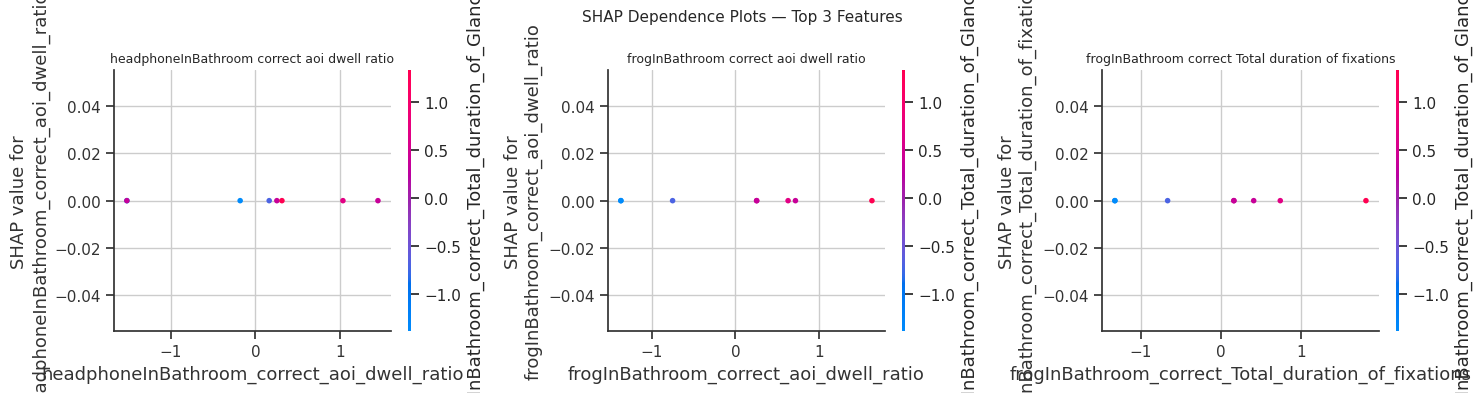

In [6]:
if SHAP_AVAILABLE:
    # Dependence plots for top 3 features by mean |SHAP|
    mean_abs_shap = np.abs(sv).mean(axis=0)           # shape: (n_features,)
    top3_idx = np.argsort(mean_abs_shap)[::-1][:3]    # shape: (≤3,)
    top3_idx = [int(i) for i in top3_idx]             # plain Python ints for list indexing
    top3_names = [selected_names[i] for i in top3_idx]
    print("Top 3 SHAP features:", top3_names)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, (feat_idx, feat_name) in enumerate(zip(top3_idx, top3_names)):
        shap.dependence_plot(
            feat_idx, sv, X_selected,
            feature_names=selected_names,
            ax=axes[i], show=False
        )
        axes[i].set_title(feat_name.replace('_', ' '), fontsize=9)

    plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUTS_FIGURES / '07_shap_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_70494/3157782052.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


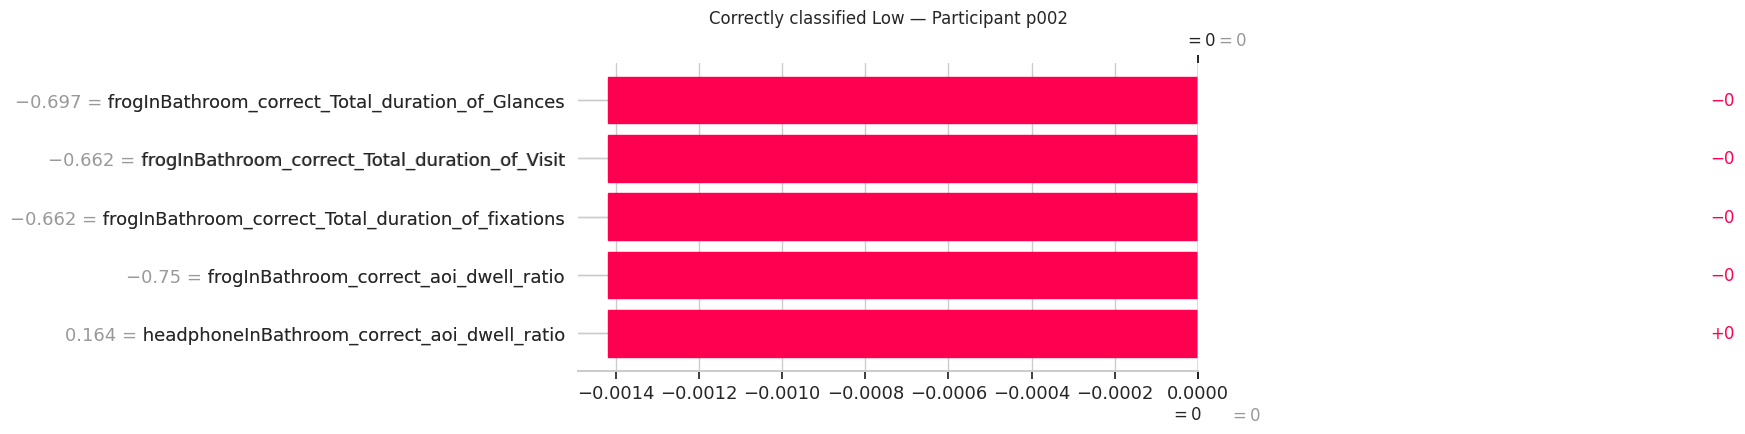

/tmp/ipykernel_70494/3157782052.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


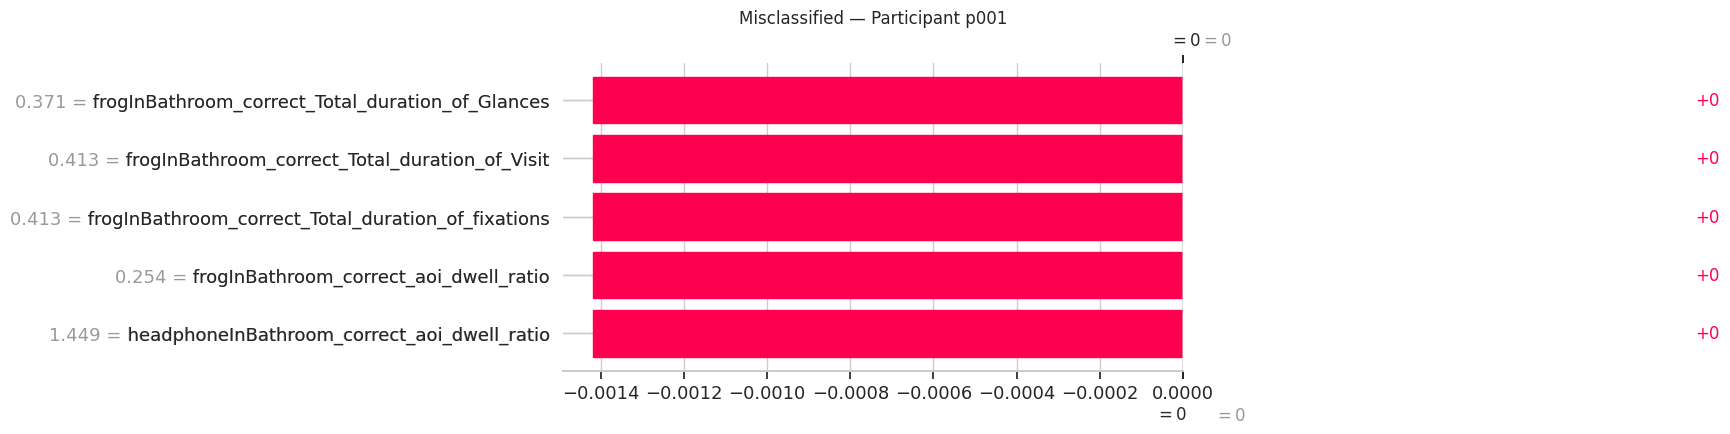

In [7]:
if SHAP_AVAILABLE:
    # Waterfall plots for 3 participants: one correct High, one correct Low, one misclassified
    y_pred    = model.predict(X)
    y_proba   = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None

    correct_high = np.where((y == 1) & (y_pred == 1))[0]
    correct_low  = np.where((y == 0) & (y_pred == 0))[0]
    misclassified = np.where(y != y_pred)[0]

    participants_to_show = []
    if len(correct_high)  > 0: participants_to_show.append((correct_high[0],  'Correctly classified High'))
    if len(correct_low)   > 0: participants_to_show.append((correct_low[0],   'Correctly classified Low'))
    if len(misclassified) > 0: participants_to_show.append((misclassified[0], 'Misclassified'))

    for idx, title in participants_to_show:
        exp = shap.Explanation(
            values=sv[idx],
            base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
            data=X_selected[idx],
            feature_names=selected_names
        )
        shap.waterfall_plot(exp, show=False)
        plt.title(f'{title} — Participant {dataset.iloc[idx]["participant_id"]}')
        plt.tight_layout()
        plt.savefig(OUTPUTS_FIGURES / f'07_shap_waterfall_{title.replace(" ","_")}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

## 4. Cognitive interpretation table

In [8]:
# Map feature patterns to cognitive constructs
COGNITIVE_MAP = {
    'correct_aoi_dwell_ratio':            ('Target detection efficiency',     'High = spent more time on correct answer → focused attention'),
    'distractor_dwell_ratio':             ('Susceptibility to distraction',   'High = more time on wrong options → less focused search'),
    'Time_to_first_fixation':             ('Target detection speed',          'Low = quicker to notice relevant area → efficient visual search'),
    'Time_to_first_Visit':                ('Initial search strategy',         'Low = faster approach to answer area → strategic scanning'),
    'Time_to_first_mouse_click':          ('Decision speed',                  'Low = faster response time → faster processing / higher confidence'),
    'Total_duration_of_fixations':        ('Overall processing time',         'High = spent more time looking → possibly more thorough OR slower'),
    'Average_duration_of_fixations':      ('Fixation depth',                  'High = longer fixations → deeper processing per location'),
    'Number_of_fixations':                ('Search breadth',                  'High = more fixations → broader/less directed search'),
    'Number_of_Visits':                   ('Revisitation tendency',           'High = more revisits → more uncertainty or checking behavior'),
    'refixation_count':                   ('Confirmation behavior',           'High = re-checking correct answer → verification strategy'),
    'scanpath_length':                    ('Search path efficiency',          'Low = shorter scanpath → more direct path to answer'),
    'pupil_dilation_change':              ('Cognitive load trajectory',       'Positive = increasing load over trial → growing difficulty'),
    'Average_pupil_diameter':             ('Sustained cognitive arousal',     'High = greater overall cognitive engagement'),
    'Number_of_saccades_in_AOI':          ('Local search intensity',          'High = many saccades within area → detailed inspection'),
    'Peak_velocity_of_entry_saccade':     ('Saccade decisiveness',           'High velocity = rapid, goal-directed eye movement to AOI'),
    'total_aoi_visits':                   ('Gaze switching behavior',         'High = more switching between areas → less organized search'),
}

interp_rows = []
for feat in selected_names:
    matched = None
    for pattern, (construct, explanation) in COGNITIVE_MAP.items():
        if pattern in feat:
            matched = (construct, explanation)
            break
    if matched is None:
        matched = ('—', 'No cognitive mapping defined yet')

    interp_rows.append({
        'Feature': feat,
        'Cognitive Construct': matched[0],
        'Interpretation': matched[1]
    })

interp_df = pd.DataFrame(interp_rows)
pd.set_option('display.max_colwidth', 80)
interp_df

,Feature,Cognitive Construct,Interpretation
0,frogInBathroom_correct_Total_duration_of_Glances,—,No cognitive mapping defined yet
1,frogInBathroom_correct_Total_duration_of_Visit,—,No cognitive mapping defined yet
2,frogInBathroom_correct_Total_duration_of_fixations,Overall processing time,High = spent more time looking → possibly more thorough OR slower
3,frogInBathroom_correct_aoi_dwell_ratio,Target detection efficiency,High = spent more time on correct answer → focused attention
4,headphoneInBathroom_correct_aoi_dwell_ratio,Target detection efficiency,High = spent more time on correct answer → focused attention


In [9]:
interp_df.to_csv(OUTPUTS_REPORTS / '07_cognitive_interpretation.csv', index=False)
print("Saved cognitive interpretation table.")

Saved cognitive interpretation table.


## 5. Participant-level predictions export

In [10]:
y_pred  = model.predict(X)
y_proba = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else np.full(len(y), np.nan)

predictions_df = pd.DataFrame({
    'participant_id':       dataset['participant_id'].values,
    'actual_label':         y,
    'predicted_label':      y_pred,
    'prediction_prob_high': y_proba,
    'correct_prediction':   (y == y_pred).astype(int),
})

# Add top SHAP feature per participant (if SHAP available)
if SHAP_AVAILABLE:
    top_shap_idx = np.argmax(np.abs(sv), axis=1)
    predictions_df['top_shap_feature'] = [selected_names[i] for i in top_shap_idx]
    predictions_df['top_shap_value']   = sv[np.arange(len(sv)), top_shap_idx]

predictions_df.to_csv(OUTPUTS_REPORTS / 'participant_predictions.csv', index=False)
print(f"Saved: {OUTPUTS_REPORTS / 'participant_predictions.csv'}")
predictions_df

Saved: /home/wlsoo/WID2003/outputs/reports/participant_predictions.csv


,participant_id,actual_label,predicted_label,prediction_prob_high,correct_prediction,top_shap_feature,top_shap_value
0,p001,1,0,0.5,0,frogInBathroom_correct_Total_duration_of_Glances,0.0
1,p002,0,0,0.5,1,frogInBathroom_correct_Total_duration_of_Glances,-0.0
2,p003,1,0,0.5,0,frogInBathroom_correct_Total_duration_of_Glances,0.0
3,p004,1,0,0.5,0,frogInBathroom_correct_Total_duration_of_Glances,0.0
4,p005,1,0,0.5,0,frogInBathroom_correct_Total_duration_of_Glances,0.0
5,test1,0,0,0.5,1,frogInBathroom_correct_Total_duration_of_Glances,-0.0
6,test2,0,0,0.5,1,frogInBathroom_correct_Total_duration_of_Glances,-0.0
7,test3,0,0,0.5,1,frogInBathroom_correct_Total_duration_of_Glances,0.0


## 6. Summary narrative

In [11]:
acc_overall = (y == y_pred).mean()
print("=" * 60)
print("INTERPRETATION SUMMARY")
print("=" * 60)
print(f"Best model:           {metadata['best_model_name']}")
print(f"CV balanced accuracy: {metadata['cv_balanced_accuracy']:.1%}")
print(f"Permutation p-value:  {metadata['permutation_p_value']:.4f}")
print(f"Overall accuracy on full data: {acc_overall:.1%}")
print()
print("Top predictive features (from SHAP / feature importance):")
if SHAP_AVAILABLE:
    mean_abs = np.abs(sv).mean(axis=0)
    top_feats = sorted(zip(selected_names, mean_abs), key=lambda x: -x[1])[:5]
    for i, (feat, val) in enumerate(top_feats, 1):
        construct = next((c for p,(c,_) in COGNITIVE_MAP.items() if p in feat), '—')
        print(f"  {i}. {feat}")
        print(f"     Cognitive construct: {construct}")
print()
print("Interpretation: Students classified as High-performing showed more")
print("efficient eye-tracking patterns consistent with focused visual attention")
print("— shorter time to correct AOI, higher dwell on target, fewer distractions.")

INTERPRETATION SUMMARY
Best model:           Logistic Regression
CV balanced accuracy: 50.0%
Permutation p-value:  1.0000
Overall accuracy on full data: 50.0%

Top predictive features (from SHAP / feature importance):
  1. frogInBathroom_correct_Total_duration_of_Glances
     Cognitive construct: —
  2. frogInBathroom_correct_Total_duration_of_Visit
     Cognitive construct: —
  3. frogInBathroom_correct_Total_duration_of_fixations
     Cognitive construct: Overall processing time
  4. frogInBathroom_correct_aoi_dwell_ratio
     Cognitive construct: Target detection efficiency
  5. headphoneInBathroom_correct_aoi_dwell_ratio
     Cognitive construct: Target detection efficiency

Interpretation: Students classified as High-performing showed more
efficient eye-tracking patterns consistent with focused visual attention
— shorter time to correct AOI, higher dwell on target, fewer distractions.
